<a href="https://colab.research.google.com/github/Zainabshiha/Diabetes-type-2-prediction-using-CNN-Conv-KAN/blob/main/CONVOLUTIONAL_KOLMOGOROV%E2%80%93ARNOLD_T2D_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#cloning the CKAN git repository
!git clone https://github.com/AntonioTepsich/Convolutional-KANs.git

Cloning into 'Convolutional-KANs'...
remote: Enumerating objects: 2400, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 2400 (delta 79), reused 64 (delta 64), pack-reused 2306 (from 2)
Receiving objects: 100% (2400/2400), 45.99 MiB | 24.76 MiB/s, done.
Resolving deltas: 100% (1295/1295), done.


In [ ]:
#this directory contains several files and directories, such as architectures_28x28, images, kan_convolutional, requirements.txt, etc.
%cd Convolutional-KANs
#installing the necessary packages
!pip install -r requirements.txt

/content/Convolutional-KANs
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 33.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 51.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 86.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 73.7 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  In

Necessary Library

In [ ]:
from architectures_28x28.CKAN_BN import CKAN_BN
from architectures_28x28.SimpleModels import *
from architectures_28x28.ConvNet import ConvNet
from architectures_28x28.KANConvs_MLP import KANC_MLP
from architectures_28x28.KKAN import KKAN_Convolutional_Network
from architectures_28x28.conv_and_kan import NormalConvsKAN
from kan_convolutional.KANConv import KAN_Convolutional_Layer
from evaluations import train_and_test_models, count_parameters, highlight_max, final_plots

Read Data

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Conv2D, MaxPooling1D,MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, Reshape
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras import regularizers
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Import the necessary DataLoader class
from torch.utils.data import DataLoader, TensorDataset
import torch
# Import the optim module
import torch.optim as optim

Model training

In [ ]:
import pandas as pd
final_data = pd.read_csv('/content/drive/MyDrive/Prediction_T2D/final_data.csv')



x = final_data.drop(['Sample', 'Output'], axis=1)

y=  final_data['Output']
# Make sure 'T2D' is included when creating train_S and test_S
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

# Verify that 'T2D' column is present in train_S
print(X_train.head(10))
print(y_train)

# Scaling numerical features
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)
# ... rest of your code ...
print("X_Total shape:", x.shape)
print("X_train shape:", X_train_scaler.shape)
print("X_test shape:", X_test_scaler.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

          Gen1       Gen2       Gen3       Gen4       Gen5       Gen6  \
68   11.007780  13.952820   9.279896   4.207865  12.469790  10.402010   
12   11.102530  13.828690   9.458462   4.360392  12.338760  10.690830   
110  57.605519  12.106379  12.202775  53.425692  38.635326  27.023045   
124  36.230394   8.842407  10.377438  44.982456  27.481300  27.033748   
27   10.846540  13.643680   8.706006   3.904666  11.558230   9.909491   
24   10.728280  13.534000   8.881124   3.872892  11.991430  10.051790   
47   10.920740  13.429620   8.541525   3.629297  11.815670  10.128210   
109  78.596771   7.574714  11.599091  89.843669  47.511992  19.692619   
123  56.084274   7.391461  11.323316  84.126542  36.337262  29.097255   
15   11.228340  13.843970   9.451311   4.178333  12.152000  10.721640   

          Gen7       Gen8       Gen9      Gen10  ...    Gen31052    Gen31053  \
68   13.511480   8.069773   9.698067   5.453889  ...    9.440150    4.371866   
12   13.351530   8.151671   9.573061

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F

from kan_convolutional.KANConv import KAN_Convolutional_Layer

class KANC_MLP(nn.Module):
    def __init__(self,grid_size: int = 5, device: str='cpu'):
        super().__init__()
        self.conv1 = KAN_Convolutional_Layer(
            in_channels=1,
            out_channels= 8,
            kernel_size= (3,3),
            grid_size = grid_size,
            stride = (1,1),
            padding = (1,1),
        )
        self.pool1 = nn.MaxPool2d(
            kernel_size=(2, 2),
            padding = (1,1),
            )

        self.conv2 = KAN_Convolutional_Layer(in_channels=8,
            out_channels= 16,
            kernel_size = (3,3),
            grid_size = grid_size,
           stride = (1,1),
            padding = (1,1),

        )

        self.pool2 = nn.MaxPool2d(
            kernel_size=(2, 2),
            padding = (1,1),

        )

        self.flat = nn.Flatten()
        self.dropout = nn.Dropout(0.5)

        self.linear1 = nn.Linear(124248, 128) #reduce units

        self.linear2 = nn.Linear(128, 1) #reduce units

        self.linear3 = nn.Linear(128, 64)
        self.linear4 = nn.Linear(64, 1)

        self.name = f"KANC MLP (Small) (gs = {grid_size})"


    def forward(self, x):

        x = self.conv1(x)
        x = self.pool1(x)
        x = self.dropout(x)
        #print("pool1:",x.shape)
        #x = self.conv2(x)
        #print("conv2:",x.shape)
        #x = self.pool2(x)
        #print("pool2:",x.shape)
        x = self.flat(x)
        #print("flat:",x.shape)
        x = self.linear1(x)
        #print("linear:",x.shape)
        x = self.linear2(x)
        #x = self.linear3(x)
        #x = self.linear4(x)
        x = self.dropout(x)
        x = torch.sigmoid(x) #remove dim=1
        #print("out:",x.shape)
        return x

#checking if GPU is available and use it if possible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#initializing the model and move it to the appropriate device
model = KANC_MLP(device=device).to(device)

# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from kan_convolutional.KANConv import KAN_Convolutional_Layer
# Assuming X_train_scaler and y_train are numpy arrays
X_train_tensor = torch.tensor(X_train_scaler, dtype=torch.float32).unsqueeze(1).unsqueeze(-1) # Reshape for CNN input
X_test_tensor = torch.tensor(X_test_scaler, dtype=torch.float32).unsqueeze(1).unsqueeze(-1) # Reshape for CNN input
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long) # Assuming y_train is a pandas Series
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long) # Assuming y_test is a pandas Series

# Create a TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create a DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
#print(X_train_tensor.shape)
#print(y_train_tensor.shape)
# Training loop

In [ ]:
# train last model with validation split then evaluate it

from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
from sklearn.metrics import f1_score, recall_score, accuracy_score, classification_report
import matplotlib.pyplot as plt

# ... (Your existing code) ...

# Assuming X_train_scaler, y_train, X_test_scaler, and y_test are defined

# Convert data to tensors and create datasets/dataloaders (already done in the original code)
# ... (Your existing data loading code) ...

# Training loop (modified to include validation)

num_epochs = 40  # Adjust as needed
training_accuracy = []
validation_accuracy = []
training_loss = []
validation_loss = []
for epoch in range(num_epochs):
    print('Epoch', epoch+1)
    # Training
    model.train()  # Set the model to training mode
    epoch_loss = 0
    correct_predictions = 0
    total_samples = 0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), labels.float())
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        predicted = (outputs > 0.5).int()
        correct_predictions += (predicted.squeeze() == labels).sum().item()
        total_samples += labels.size(0)
    train_acc = correct_predictions / total_samples
    training_accuracy.append(train_acc)
    training_loss.append(epoch_loss/len(train_loader))

    # Validation
    model.eval() # Set the model to evaluation mode
    with torch.no_grad():
      val_loss = 0
      val_correct = 0
      val_total = 0
      for inputs, labels in test_loader:
          inputs, labels = inputs.to(device), labels.to(device)
          outputs = model(inputs)
          loss = criterion(outputs.squeeze(), labels.float())
          val_loss += loss.item()
          predicted = (outputs > 0.5).int()
          val_correct += (predicted.squeeze() == labels).sum().item()
          val_total += labels.size(0)

    val_acc = val_correct / val_total
    validation_accuracy.append(val_acc)
    validation_loss.append(val_loss/len(test_loader))

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss/len(train_loader):.4f}, Train Accuracy: {train_acc:.4f}, Val Loss: {val_loss/len(test_loader):.4f}, Val Accuracy: {val_acc:.4f}')


# ... (rest of your evaluation code, no changes needed)


Epoch 1
Epoch [1/40], Train Loss: 3.3011, Train Accuracy: 0.4800, Val Loss: 1.4467, Val Accuracy: 0.4615
Epoch 2
Epoch [2/40], Train Loss: 1.9959, Train Accuracy: 0.5600, Val Loss: 1.8168, Val Accuracy: 0.5385
Epoch 3
Epoch [3/40], Train Loss: 2.5902, Train Accuracy: 0.5300, Val Loss: 1.0320, Val Accuracy: 0.4231
Epoch 4
Epoch [4/40], Train Loss: 1.0978, Train Accuracy: 0.5000, Val Loss: 1.2328, Val Accuracy: 0.5385
Epoch 5
Epoch [5/40], Train Loss: 1.0058, Train Accuracy: 0.5300, Val Loss: 1.5410, Val Accuracy: 0.5385
Epoch 6
Epoch [6/40], Train Loss: 1.5889, Train Accuracy: 0.5700, Val Loss: 1.2194, Val Accuracy: 0.5385
Epoch 7
Epoch [7/40], Train Loss: 0.8006, Train Accuracy: 0.5900, Val Loss: 0.7905, Val Accuracy: 0.5000
Epoch 8
Epoch [8/40], Train Loss: 0.6876, Train Accuracy: 0.5200, Val Loss: 0.7952, Val Accuracy: 0.5769
Epoch 9
Epoch [9/40], Train Loss: 0.6792, Train Accuracy: 0.6700, Val Loss: 0.6802, Val Accuracy: 0.7308
Epoch 10
Epoch [10/40], Train Loss: 0.5894, Train Accur

In [ ]:
import torch
from sklearn.metrics import f1_score, recall_score, classification_report, accuracy_score

# Assuming X_test_scaler and y_test are numpy arrays
X_test_tensor = torch.tensor(X_test_scaler, dtype=torch.float32).unsqueeze(1).unsqueeze(-1).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

# Make predictions on the test set
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    y_pred_probs = model(X_test_tensor)
    y_pred = (y_pred_probs > 0.5).int().squeeze()

# Calculate metrics
f1 = f1_score(y_test_tensor.cpu(), y_pred.cpu())
recall = recall_score(y_test_tensor.cpu(), y_pred.cpu())
accuracy = accuracy_score(y_test_tensor.cpu(), y_pred.cpu())

print(f"F1-score: {f1}")
print(f"Recall: {recall}")
print(f"Accuracy: {accuracy}")

print("Classification Report:\n", classification_report(y_test_tensor.cpu(), y_pred.cpu()))

F1-score: 0.9565217391304348
Recall: 0.9166666666666666
Accuracy: 0.9615384615384616
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.92      0.96        12

    accuracy                           0.96        26
   macro avg       0.97      0.96      0.96        26
weighted avg       0.96      0.96      0.96        26



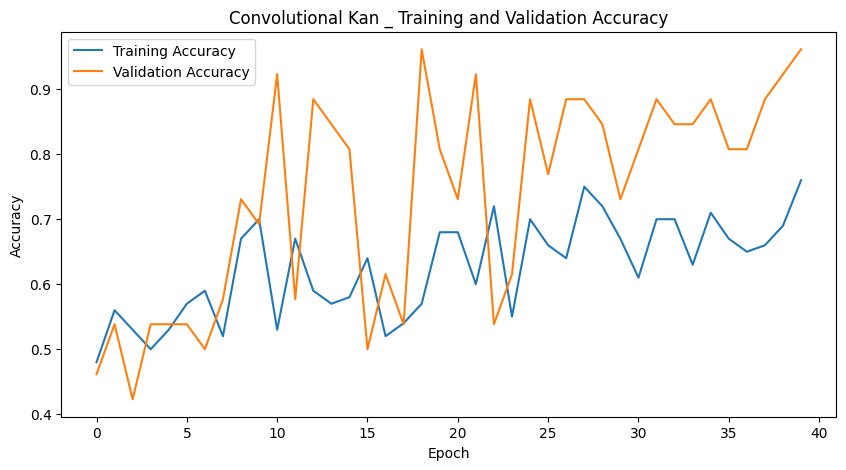

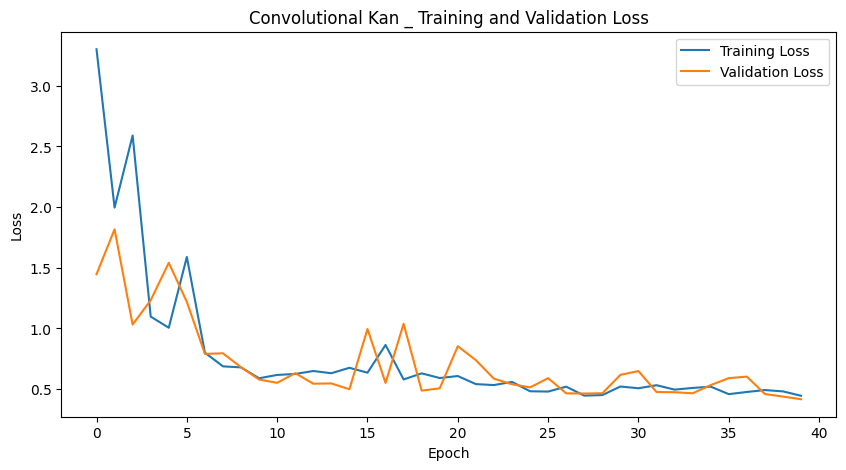

In [ ]:
# Make plots for last train

import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(training_accuracy, label='Training Accuracy')
plt.plot(validation_accuracy, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Convolutional Kan _ Training and Validation Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Convolutional Kan _ Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
import pickle  # Import the pickle module
# Save model
model_kan_96 = '/content/drive/MyDrive/Prediction_T2D/Saved_Models/model_kan_96_1.pth'  # Change to .pth extension for PyTorch models
torch.save(model.state_dict(), model_kan_96)

# Save training history
history_save_path = '/content/drive/MyDrive/Prediction_T2D/Saved_Models/train_model_kan_96_1.pkl'  # Replace with your desired path
with open(history_save_path, 'wb') as file:
    pickle.dump(model, file)